## Module_3

## Team Members:
Isabella Imburgia and Isabella Orlando

## Project Title: Interpolating Lung Fibrosis in Mouse Models




## Project Goal:
This project seeks to develop an image analysis pipeline that will predict the degree of idiopathic lung fibrosis at different biopsy depths from the top of the lung.

## AI Usage Statement:
Generative AI (Chat GPT) was used to edit the original code in order to increase proficiency and assist with debugging code.

## Disease Background: 


* Prevalence & incidence: 
    * Global incidence estimates are around 5.8 for 100,000 individuals (.0058%) per year [1]
    * Global prevalence suggests 17.7 for 100,000 individuals (.0177)
* Risk factors (genetic, lifestyle) 
    * Old age, being male, smoking, family history of IPF [2]
* Symptoms: 
    * Difficulty breathing, persistent dry cough, fatigue, cyanosis, digital clubbing
* Diagnosis:
    * An early sign is a distinct crackling sound in the lungs, called rales [3]
    * Chest imaging, a CT scan or Chest X-ray, can depict "honeycombing", or fluid buildup in the alveoli, as well as thickening of interstitial walls
    * Pulmonary Function Test measures how much air you can inhale and exhale. 
        * Can reveal a decrease in total lung capacity, forced vital capacity, and forced expiratory volume
* Standard of care treatment(s): 
    * Damage from scarring is irreversible
    * There is no cure to IPF besides a lung transplant
    * Treatments to slow disease progression and improve quality of life include supplemental oxygen, pulmonary rehabilitation, and FDA-approved medicines
* Disease progression and prognosis: 
    * Chronic disease that can cause permanent scarring in the lungs that makes it progressively more difficult to breathe
    * Timing of the progression of the disease varies in each person but typically symptoms worsen over time
    * severe complications of IPF include pulmonary hypertension and respiratory failure
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)
    * Gas exchange occurs between alveoli and capillaries
        * When interstitial lining between becomes damaged, Type II pneumocytes from the alveoli stimulate myofibroblast production followed by apoptosis [4]
        * Myofibroblasts secrete collagen that provides structural strength and elasticity for the lung tissue 
    * Type II pneumocytes overproliferate, leading to excess mirofibroblasts and collagen production
    * Mirofibroblasts do not undergo aptosis and continue to produce excess collagen
    * Collagen accumulates and thickens the interstitial layer
    * Lung tissue becomes stiff and respiration becomes increasingly difficult as lungs lose healthy tissue
        * Total lung capacity, forced vital capacity, and forced expiratory volume decrease

## Data-Set: 
Unpublished data was collected by the Peirce-Cottler Lab (Dept. of Biomedical Engineering) and Kim Lab (Division of Pulmonary and Critical Care) at the University of Virginia School of Medicine. 

78 black and white images were collected at different depths into a fibrotic mouse long where white indicates a fibrotic lesion and black indicates healthy lung tissue. Because the data was collected from mice models, there are limitations that shuold be considered when making generalizations and inferations for human lungs. Mice lungs were injected with bleomycin, an antibiotic that causes lung fibrosis, and after 3 weeks the lungs were fixed with paraformaldehyde. They were sliced from 0 to 10,000 microns and placed into a slide, where an immunofluorescence procedure was conducted to stain myofibroblasts, blood vessels, and endothelial cells in all blood vessels.

## Data Analyis: 

### Step 1: Load Images and Calculate % White Pixels

In [32]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time

start = time.time()

# Load the images you want to analyze

filenames = [
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010093.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010118.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010140.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010157.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010134.jpg",
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010146.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010093.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010118.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010140.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010157.jpg",
]

# Enter the depth of each image (in the same order that the images are listed above; you can find these in the .csv file provided to you which is tilted: "Filenames and Depths for Students")

depths = [
    100,
    860,
    9300,
    9900,
    8300,
    750,
    6600,
    #2000,
]

# Make sure the lists match
if len(filenames) != len(depths):
    raise ValueError("The number of filenames does not match the number of depths.")
# Make the lists that will be used

images = []
white_counts = []
black_counts = []
white_percents = []

# Build the list of all the images you are analyzing

# For each filename in the list of filenames, load the image and add it to the list of images. If the image cannot be loaded, raise an error.
for filename in filenames:
    img = cv2.imread(filename, 0)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {filename}")
    images.append(img)

# For each image (until the end of the list of images), calculate the number of black and white pixels and make a list that contains this information for each filename.
start = time.time()
for x in range(len(filenames)):
    _, binary = cv2.threshold(images[x], 127, 255, cv2.THRESH_BINARY)
    
    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white
    white_percent = (white / total) * 100

# Calculate the percentage of pixels in each image that are white and make a list that contains these percentages for each filename
    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_percent)
end = time.time()

print(f"Processing time (no I/O): {end - start:.6f} seconds")
# Print the number of white and black pixels in each image.

print(colored("Counts of pixel by color in each image", "yellow"))
for x in range(len(filenames)):
    print(colored(f"White pixels in image {x}: {white_counts[x]}", "white"))
    print(colored(f"Black pixels in image {x}: {black_counts[x]}", "red"))
    print()

# Print the filename (on one line in red font), and below that line print the percent white pixels and depth into the lung where the image was obtained

print(colored("Percent white px:", "yellow"))
for x in range(len(filenames)):
    print(colored(f'{filenames[x]}:', "red"))
    print(f'{white_percents[x]}% White | Depth: {depths[x]} microns')
    print()

'''Write your data to a .csv file'''

# Create a DataFrame that includes the filenames, depths, and percentage of white pixels
df = pd.DataFrame({
    'Filenames': filenames,
    'Depths': depths,
    'White percents': white_percents
})

# Write that DataFrame to a .csv file

df.to_csv('Percent_White_Pixels.csv', index=False)

print("The .csv file 'Percent_White_Pixels.csv' has been created.")


Processing time (no I/O): 0.032981 seconds
Counts of pixel by color in each image
White pixels in image 0: 37508
Black pixels in image 0: 4156796

White pixels in image 1: 59426
Black pixels in image 1: 4134878

White pixels in image 2: 168932
Black pixels in image 2: 4025372

White pixels in image 3: 237289
Black pixels in image 3: 3957015

White pixels in image 4: 139818
Black pixels in image 4: 4054486

White pixels in image 5: 56419
Black pixels in image 5: 4137885

White pixels in image 6: 91653
Black pixels in image 6: 4102651

Percent white px:
C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg:
0.8942604064941406% White | Depth: 100 microns

C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg:
1.4168262481689453% White | Depth: 860 microns

C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibros

Using the provided images of mouse lungs taken at different depths, the percentage of white pixels present in the photos was calculated. This represents fibrotic lung tissue in the mouse model which was written to a csv file contaning the file name, depth, and percent lung firbrosis. 

### Step 2: Interpolate the data and plot it

The interpolated point using linear interpolation is at the x-coordinate 2000 and y-coordinate 1.56942568589586.


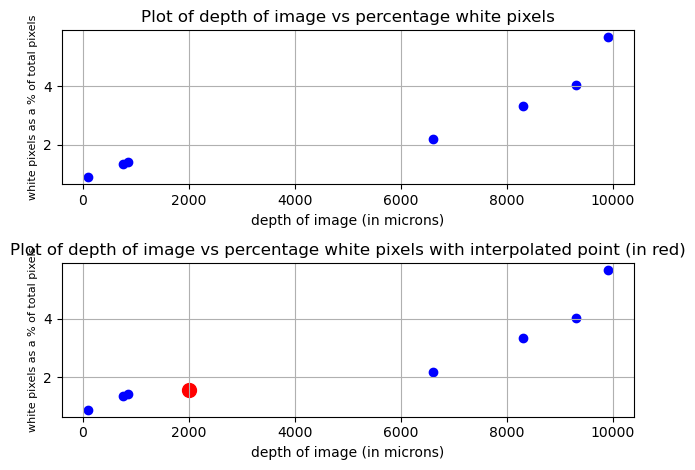

The interpolated point using quadratic interpolation is at the x-coordinate 2000 and y-coordinate 1.9226998991518203.


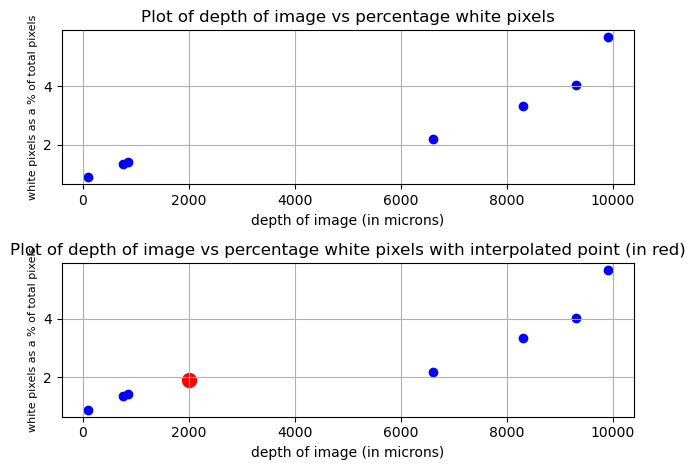

The interpolated point using cubic interpolation is at the x-coordinate 2000 and y-coordinate 1.8469453401555795.


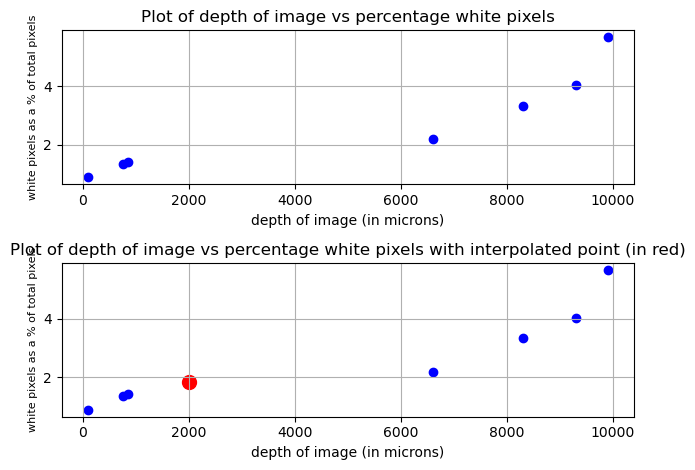

In [33]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time

interpolate_depth = 2000


x = depths
y = white_percents

# LINEAR INTERPOLATION
i = interp1d(x, y, kind='linear')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point using linear interpolation is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# QUADRATIC INTERPOLATION
i = interp1d(x, y, kind='quadratic')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point using quadratic interpolation is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

# CUBIC INTERPOLATION
i = interp1d(x, y, kind='cubic')
interpolate_point = i(interpolate_depth)
print(colored(
     f'The interpolated point using cubic interpolation is at the x-coordinate {interpolate_depth} and y-coordinate {interpolate_point}.', "green"))

depths_i = depths[:]
depths_i.append(interpolate_depth)
white_percents_i = white_percents[:]
white_percents_i.append(interpolate_point)


# # make two plots: one that doesn't contain the interpolated point, just the data calculated from your images, and one that also contains the interpolated point (shown in red)
fig, axs = plt.subplots(2, 1)

axs[0].scatter(depths, white_percents, marker='o', linestyle='-', color='blue')
axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[0].grid(True)


axs[1].scatter(depths_i, white_percents_i, marker='o',
                linestyle='-', color='blue')
axs[1].set_title(
     'Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[1].grid(True)
axs[1].scatter(depths_i[len(depths_i)-1], white_percents_i[len(white_percents_i)-1],
                color='red', s=100, label='Highlighted point')


# # Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

The three different types of interpolation give slightly different results for the value of white pixels as a percentage of total pixels. The next step is to determine which type of interpolation is the most accurate for this data set. 

### Step 3: Compare Interpolated Values to Real Value

In [ ]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time

start = time.time()

# Load the images you want to analyze

filenames = [
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg",
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010093.jpg",
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010118.jpg",
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010140.jpg",
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010157.jpg",
    #r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010134.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010146.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010093.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010118.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010140.jpg",
    #r"C:\Users\isabe\OneDrive\Documents\BME2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010157.jpg",
]

# Enter the depth of each image (in the same order that the images are listed above; you can find these in the .csv file provided to you which is tilted: "Filenames and Depths for Students")

depths = [
    #100,
    #860,
    #9300,
    #9900,
    #8300,
    #750,
    #6600,
    2000,
]

# Make sure the lists match
if len(filenames) != len(depths):
    raise ValueError("The number of filenames does not match the number of depths.")
# Make the lists that will be used

#initialize the lists that will be used
images = []
white_counts = []
black_counts = []
white_percents = []

# Build the list of all the images you are analyzing

# For each filename in the list of filenames, load the image and add it to the list of images. If the image cannot be loaded, raise an error.
for filename in filenames:
    img = cv2.imread(filename, 0)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {filename}")
    images.append(img)

# For each image (until the end of the list of images), calculate the number of black and white pixels and make a list that contains this information for each filename.
start = time.time()
for x in range(len(filenames)):
    _, binary = cv2.threshold(images[x], 127, 255, cv2.THRESH_BINARY)
    
    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white
    white_percent = (white / total) * 100

# Calculate the percentage of pixels in each image that are white and make a list that contains these percentages for each filename
    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_percent)



# Print the number of white and black pixels in each image.

print(colored("Counts of pixel by color in each image", "yellow"))
for x in range(len(filenames)):
    print(colored(f"White pixels in image {x}: {white_counts[x]}", "white"))
    print(colored(f"Black pixels in image {x}: {black_counts[x]}", "red"))
    print()

# Print the filename (on one line in red font), and below that line print the percent white pixels and depth into the lung where the image was obtained

print(colored("Percent white px:", "yellow"))
for x in range(len(filenames)):
    print(colored(f'{filenames[x]}:', "red"))
    print(f'{white_percents[x]}% White | Depth: {depths[x]} microns')
    print()


Processing time (no I/O): 0.005981 seconds
Counts of pixel by color in each image
White pixels in image 0: 62913
Black pixels in image 0: 4131391

Percent white px:
C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010146.jpg:
1.4999628067016602% White | Depth: 2000 microns



In [35]:
error_lin = (abs((1.56942568589586 - 1.4999628067016602))/(1.4999628067016602)) * 100
print("The percent error for the linear interpolation is", error_lin, "%")
error_quad = (abs((1.9226998991518203 - 1.4999628067016602))/(1.4999628067016602)) * 100
print("The percent error for the quadratic interpolation is", error_quad, "%")
error_cubic = (abs((1.8469453401555795 - 1.4999628067016602))/(1.4999628067016602)) * 100
print("The percent error for the cubic interpolation is", error_cubic, "%")

The percent error for the linear interpolation is 4.630973440397835 %
The percent error for the quadratic interpolation is 28.183171646751486 %
The percent error for the cubic interpolation is 23.13274248558975 %


It is evident that the linear interpolation is closest to the true value of percent white pixels at a depth of 2000 microns. 

### Step 4: Use linear interpolation to find more data points

Interpolated point: depth = 2000, white pixel % = 1.5694
Interpolated point: depth = 3000, white pixel % = 1.7033
Interpolated point: depth = 4000, white pixel % = 1.8371
Interpolated point: depth = 5000, white pixel % = 1.9710
Interpolated point: depth = 7000, white pixel % = 2.4554
Interpolated point: depth = 8000, white pixel % = 3.1309
Interpolated point: depth = 9000, white pixel % = 3.8194

Interpolated Results:
   Depth  Interpolated White %
0   2000              1.569426
1   3000              1.703285
2   4000              1.837144
3   5000              1.971003
4   7000              2.455376
5   8000              3.130872
6   9000              3.819413


C:\Users\ajq2af\AppData\Local\Temp\ipykernel_9840\276132611.py:121: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs[1].legend()


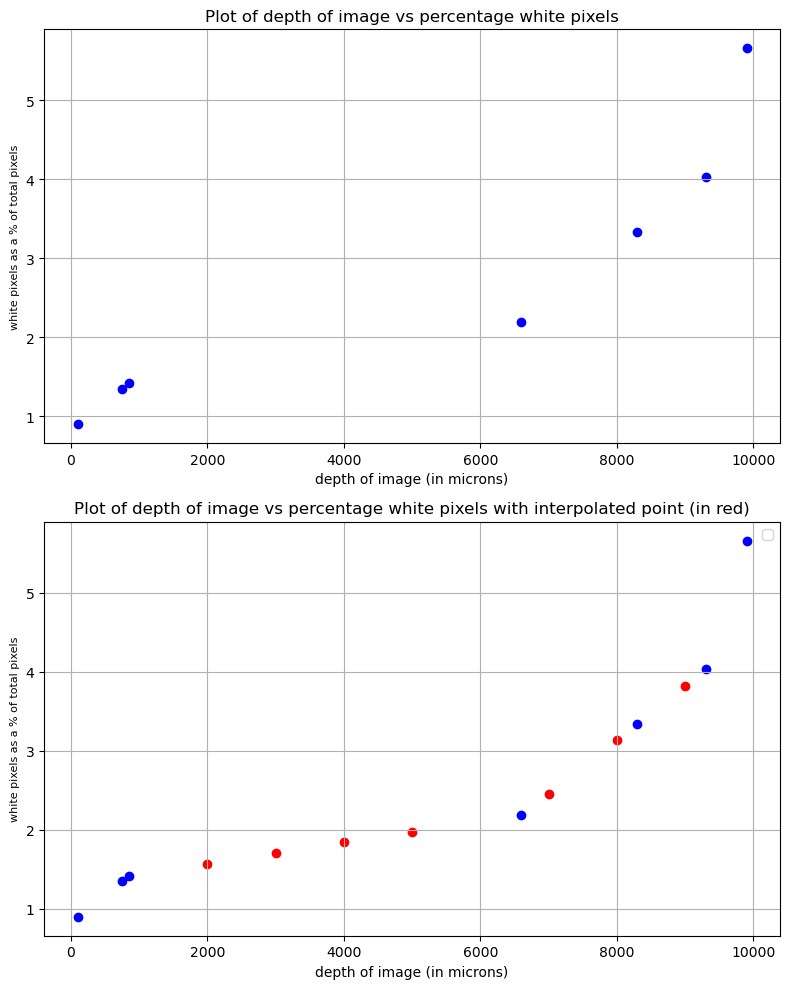

In [ ]:
from termcolor import colored
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import pandas as pd
import time


start = time.time()

# Load the images you want to analyze
filenames = [
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_Sk658 Llobe ch010023.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010159.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010093.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010118.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010140.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010157.jpg",
    r"C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-3-Fibrosis\images\MASK_SK658 Slobe ch010134.jpg",
]

# Enter the depth of each image (same order as filenames)
depths = [
    100,
    860,
    9300,
    9900,
    8300,
    750,
    6600,
]

# Enter multiple depths to interpolate
interpolate_depths = [2000, 3000, 4000, 5000, 7000, 8000, 9000]

# Make sure the lists match
if len(filenames) != len(depths):
    raise ValueError("The number of filenames does not match the number of depths.")

# sort by depth before interpolation to ensure the interpolation function works correctly
paired = sorted(zip(depths, filenames), key=lambda x: x[0])
depths = [p[0] for p in paired]
filenames = [p[1] for p in paired]

# initialize the lists that will be used
images = []
white_counts = []
black_counts = []
white_percents = []

# Load images
for filename in filenames:
    img = cv2.imread(filename, 0)
    if img is None:
        raise FileNotFoundError(f"Could not load image: {filename}")
    images.append(img)

# Calculate white and black pixels for each image
for i_img in range(len(filenames)):
    _, binary = cv2.threshold(images[i_img], 127, 255, cv2.THRESH_BINARY)

    white = np.count_nonzero(binary == 255)
    total = binary.size
    black = total - white
    white_percent = (white / total) * 100

    white_counts.append(white)
    black_counts.append(black)
    white_percents.append(white_percent)

# Convert to arrays for interpolation
x = np.array(depths)
y = np.array(white_percents)

# Make interpolation function
interp_func = interp1d(x, y, kind='linear', fill_value="extrapolate")

# Compute all interpolated points
interpolated_points = []
for d in interpolate_depths:
    y_interp = float(interp_func(d))
    interpolated_points.append((d, y_interp))
    print(colored(
        f'Interpolated point: depth = {d}, white pixel % = {y_interp:.4f}',
        "green"
    ))

# Put interpolation results in a DataFrame
interp_df = pd.DataFrame(interpolated_points, columns=["Depth", "Interpolated White %"])
print("\nInterpolated Results:")
print(interp_df)

# Combine original + interpolated data for second plot
depths_i = list(depths) + [pt[0] for pt in interpolated_points]
white_percents_i = list(white_percents) + [pt[1] for pt in interpolated_points]

# Create plots
fig, axs = plt.subplots(2, 1, figsize=(8, 10))

# Plot 1: original data only
axs[0].scatter(depths, white_percents, color='blue')

axs[0].set_title('Plot of depth of image vs percentage white pixels')
axs[0].set_xlabel('depth of image (in microns)')
axs[0].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[0].grid(True)

# Plot 2: original data + interpolated points
axs[1].scatter(depths, white_percents, color='blue')


interp_x = [pt[0] for pt in interpolated_points]
interp_y = [pt[1] for pt in interpolated_points]

axs[1].scatter(interp_x, interp_y, marker='o', linestyle='-', color='red')
axs[1].set_title('Plot of depth of image vs percentage white pixels with interpolated point (in red)')
axs[1].set_xlabel('depth of image (in microns)')
axs[1].set_ylabel('white pixels as a % of total pixels', fontsize=8)
axs[1].grid(True)
axs[1].legend()

plt.tight_layout()
plt.show()





## Verify and validate your analysis: 

To verify our data analysis, we interpolated a data point whose true value was included in the dataset using a linear, quadratic, and cubic model. We compared these interpolation models by calculating percent error between the interpolated value and the true value to determine which best fit the dataset. The linear model clearly produced the lowest percent error value which indicates it is the most reliable fit for our dataset. This was further verified by interpolating points with varying depths and confirming visually whether the linear trend appropriately represented the relationship between depth of biopsy and the true percentage of white pixels. Interpolated values that weren't included in the graph were then generated to visualize the trend.
The values of interpolated data points were compared to points of the same depth to validate the accuracy of the model in predicting values. The overall upward trend in fibrotic tissue as depth increases was also seen throughout the dataset. The biological mechanisms that develop fibrosis in the lungs occur in the alveoli, as an overproduction of collagen causes the tissue to become scarred and stiff. Research indicates alveoli are located within the deeper tissues of the lung where gas exchange occurs, which supports the hypothesis that fibrosis begins in deeper layer of the lung [5].

## Conclusions and Ethical Implications: 
The analysis shows that the percentage of white pixels increases as the depth of the image increases. This leads to the conclusion that there is more fibrotic tissue deeper in the lungs of mice models. Early fibrosis commonly affects the periperhal tissue, but as the chronic disease progresses the deeper lung tissue becomes more inflammed. 
Ethical implications of this analysis include the application of this data to conducting lung biopsies. There are many instances where IPF is undiagnosed in its initial stages because there are many shared symptoms with other cardiac or respiratory diseases. By understanding locations where IPF tissue is more likely to occur, it may decrease the chance of receiving a false negative diagnosis. Additionally, if a chest imaging procedure is done, significant fibrotic tissue will appear but deeper, mild or microscopic fibrotic tissue may not be visible on the chest scan. In the use of this data and analysis to guide the development of a new biopsy device, it would be recommended to create a device that can reach greater depths due to the evidence of a greater accumulation of fibrotic tissue deeper in the lungs. 

## Limitations and Future Work: 
The data set is limited by the fact that the images contain noise in the form of blood vessels and other tissue, so the white pixels do not strictly represent fibrotic tissue. Given more time, it would be beneficial to filter the images before calculating the percent of white pixels to have a more accurately represented data set. It would also be interesting to see if it is possible to accurately extrapolate values at further depths or explore lung fibrosis in human models compared to the mice models if the data is available.

## References:
[1] N. Golchin et al., “Incidence and prevalence of idiopathic pulmonary fibrosis,” BMC Pulmonary Medicine, 2025.

[2] National Heart, Lung, and Blood Institute, “Idiopathic Pulmonary Fibrosis,” [Online]. Available: https://www.nhlbi.nih.gov/health/idiopathic-pulmonary-fibrosis

[3] YouTube, “Idiopathic Pulmonary Fibrosis (IPF) explanation,” [Online Video]. Available: https://www.youtube.com/watch?v=s2owdwl5Vac

[4] YouTube, “Pulmonary fibrosis / lung scarring overview,” [Online Video]. Available: https://www.youtube.com/watch?v=Z6_0WkceY88

[5] Cleveland Clinic, “Lungs: Anatomy, Function & Structure,” [Online]. Available: https://my.clevelandclinic.org/health/body/8960-lungs